
# PMF $3\times3$ generalized eigensystem benchmark
## CPU and PyCUDA: LU + Lebedev vs Cholesky + Cardano

This notebook benchmarks the **complete eigenvalue–eigenvector chain** required by a
polarimetric matched-filter type problem,

\[
H w = \lambda G w,
\qquad
G=G^H>0,\qquad H=H^H\succeq 0 .
\]

The equivalent standard problem is

\[
A w=\lambda w,\qquad A=G^{-1}H,
\]

where \(A\) is generally non-Hermitian.

Two complete solution routes are compared on **CPU and GPU**:

### Route 1 — direct non-Hermitian formulation
\[
(G,H)
\overset{\mathrm{LU/solve}}{\longrightarrow}
A=G^{-1}H
\overset{\mathrm{Lebedev}}{\longrightarrow}
\lambda_i
\overset{\mathrm{null}(A-\lambda_i I)}}{\longrightarrow}
w_i .
\]

### Route 2 — structure-preserving formulation
\[
G=LL^H,\qquad
C=L^{-1}HL^{-H}=C^H,
\]
\[
C y_i=\lambda_i y_i
\overset{\mathrm{Cardano}}{\longrightarrow}
(\lambda_i,y_i),
\qquad
w_i=L^{-H}y_i .
\]

The Cardano-like Hermitian solver is the same analytical strategy used in the
earlier \(3\times3\) Hermitian GPU work: real characteristic-polynomial
coefficients, closed-form cubic roots, and cross products for the eigenvectors.

The notebook measures:

- CPU time for the **full chain** of each route;
- GPU **kernel-only** time for the full chain;
- GPU **end-to-end** time, including H2D and D2H transfers;
- CPU-to-GPU speedup;
- Lebedev-vs-Cardano timing ratios;
- eigenvalue accuracy;
- generalized eigenpair residuals;
- \(G\)-orthogonality;
- phase-invariant eigenvector error;
- dominant-eigenvector accuracy, which is the most relevant quantity for the matched filter.

All custom CPU/GPU calculations use single precision (`complex64`/`float32`).
A double-precision structure-preserving eigensolution is used only as a numerical reference.



## 1. Colab / CUDA setup

In Google Colab select **Runtime → Change runtime type → GPU**.

The cell below installs PyCUDA automatically when it is not already present.
The notebook deliberately reports the CUDA device and stops before the GPU benchmark
if no CUDA device is available, so a CPU-only execution cannot be mistaken for the
intended GPU experiment.


In [1]:
!pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 25.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 11.2 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp313-cp313-linux_x86_64.whl size=5281390 sha256=b4091c18880f856b88a53058498281b6ce260ef24e376e941c75ff8baf61b35c
  Stored in directory: /root/.cache/pip/wheels/ce/26/46/c519675fcb0e5e17bab8e85b6676528c40d12d794182340e85
Successfully built pycuda


In [2]:

import sys, subprocess, importlib.util, time, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Install PyCUDA automatically when needed.
if importlib.util.find_spec("pycuda") is None:
    print("PyCUDA not found: installing it...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pycuda"])

GPU_AVAILABLE = False
GPU_ERROR = None
try:
    import pycuda.driver as cuda
    cuda.init()
    if cuda.Device.count() > 0:
        import pycuda.autoinit
        from pycuda.compiler import SourceModule
        GPU_AVAILABLE = True
        GPU_NAME = cuda.Device(0).name()
        GPU_CC = cuda.Device(0).compute_capability()
    else:
        GPU_ERROR = RuntimeError("No CUDA device was detected.")
except Exception as exc:
    GPU_ERROR = exc

print("NumPy:", np.__version__)
if GPU_AVAILABLE:
    print("CUDA device:", GPU_NAME)
    print("Compute capability:", GPU_CC)
else:
    print("CUDA unavailable:", repr(GPU_ERROR))


NumPy: 2.1.3
CUDA device: Tesla T4
Compute capability: (7, 5)



## 2. Benchmark parameters


In [3]:

SEED = 12345

# Large batches are useful because the target workload is pixelwise and massively parallel.
BATCH_SIZES = [1_000, 10_000, 100_000, 1_000_000]

# Accuracy check uses a smaller batch to keep the reference inexpensive.
N_CHECK = 10_000

CPU_REPEATS = 3
GPU_REPEATS = 9
BLOCK_SIZE = 256

# Positive diagonal loading of G.
SPD_SHIFT = np.float32(0.75)

# Lebedev near-degenerate threshold.
TAU_EPS = np.float32(2.0e-6)

# Individual eigenvector comparisons are disabled close to repeated eigenvalues.
EIGENGAP_TOL = np.float32(1.0e-4)

np.set_printoptions(precision=6, suppress=True)



## 3. Matrix-pair generator

The test matrices reproduce the structure relevant to the generalized Hermitian problem.

\[
G=R R^H+\delta I>0,\qquad H=S S^H\succeq0.
\]

Both matrices are trace-normalized before the diagonal loading of \(G\), in order to
avoid irrelevant global scaling and to keep the numerical range representative of
well-scaled covariance/coherency matrices.


In [4]:

def _random_complex(n, rng, dtype=np.complex64):
    real = rng.standard_normal((n, 3, 3)).astype(np.float32)
    imag = rng.standard_normal((n, 3, 3)).astype(np.float32)
    return (real + 1j*imag).astype(dtype)


def _trace_normalize(M):
    tr = np.trace(M, axis1=1, axis2=2).real.astype(np.float32) / np.float32(3.0)
    tr = np.maximum(tr, np.float32(1e-7))
    return M / tr[:, None, None]


def generate_pair(n, rng, shift=SPD_SHIFT):
    R = _random_complex(n, rng)
    G = R @ np.swapaxes(R.conj(), 1, 2)
    G = _trace_normalize(G)
    G = G + shift*np.eye(3, dtype=np.complex64)[None, :, :]

    S = _random_complex(n, rng)
    H = S @ np.swapaxes(S.conj(), 1, 2)
    H = _trace_normalize(H)

    return (
        np.ascontiguousarray(G, dtype=np.complex64),
        np.ascontiguousarray(H, dtype=np.complex64),
    )



## 4. Common CPU helpers

The CPU routines below implement the same mathematics as the CUDA kernels.
They are intentionally written in batched NumPy form so that the comparison is between
the two mathematical routes rather than between unrelated library eigensolvers.


In [5]:

def form_A_cpu(G,H):
    """Explicit batched 3x3 Doolittle LU solve for A = G^{-1}H."""
    g00,g01,g02 = G[:,0,0],G[:,0,1],G[:,0,2]
    g10,g11,g12 = G[:,1,0],G[:,1,1],G[:,1,2]
    g20,g21,g22 = G[:,2,0],G[:,2,1],G[:,2,2]

    u00 = g00
    u01 = g01
    u02 = g02
    l10 = g10/u00
    l20 = g20/u00
    u11 = g11-l10*u01
    u12 = g12-l10*u02
    l21 = (g21-l20*u01)/u11
    u22 = g22-l20*u02-l21*u12

    A = np.empty_like(H,dtype=np.complex64)

    for j in range(3):
        y0 = H[:,0,j]
        y1 = H[:,1,j]-l10*y0
        y2 = H[:,2,j]-l20*y0-l21*y1

        x2 = y2/u22
        x1 = (y1-u12*x2)/u11
        x0 = (y0-u01*x1-u02*x2)/u00

        A[:,0,j] = x0
        A[:,1,j] = x1
        A[:,2,j] = x2

    return np.ascontiguousarray(A,dtype=np.complex64)


def cholesky_reduce_cpu(G,H):
    """Explicit batched Cholesky and C=L^{-1}HL^{-H}."""
    l00 = np.sqrt(np.maximum(G[:,0,0].real,np.float32(1e-30))).astype(np.float32)
    l10 = G[:,1,0]/l00
    l20 = G[:,2,0]/l00

    t11 = G[:,1,1].real-np.abs(l10)**2
    l11 = np.sqrt(np.maximum(t11,np.float32(1e-30))).astype(np.float32)

    l21 = (G[:,2,1]-l20*np.conj(l10))/l11

    t22 = G[:,2,2].real-np.abs(l20)**2-np.abs(l21)**2
    l22 = np.sqrt(np.maximum(t22,np.float32(1e-30))).astype(np.float32)

    Y = np.empty_like(H,dtype=np.complex64)
    for j in range(3):
        Y[:,0,j] = H[:,0,j]/l00
        Y[:,1,j] = (H[:,1,j]-l10*Y[:,0,j])/l11
        Y[:,2,j] = (
            H[:,2,j]-l20*Y[:,0,j]-l21*Y[:,1,j]
        )/l22

    C = np.empty_like(H,dtype=np.complex64)
    for r in range(3):
        C[:,r,0] = Y[:,r,0]/l00
        C[:,r,1] = (
            Y[:,r,1]-C[:,r,0]*np.conj(l10)
        )/l11
        C[:,r,2] = (
            Y[:,r,2]
            -C[:,r,0]*np.conj(l20)
            -C[:,r,1]*np.conj(l21)
        )/l22

    # Remove only anti-Hermitian roundoff.
    C = np.float32(0.5)*(C+np.swapaxes(C.conj(),1,2))
    for j in range(3):
        C[:,j,j] = C[:,j,j].real.astype(np.float32)

    L = np.zeros_like(G,dtype=np.complex64)
    L[:,0,0] = l00
    L[:,1,0] = l10
    L[:,1,1] = l11
    L[:,2,0] = l20
    L[:,2,1] = l21
    L[:,2,2] = l22

    return np.ascontiguousarray(L),np.ascontiguousarray(C)


def backtransform_cpu(L,Y):
    """Explicit solve L^H W = Y for all three eigenvectors."""
    l00 = L[:,0,0].real.astype(np.float32)
    l10 = L[:,1,0]
    l11 = L[:,1,1].real.astype(np.float32)
    l20 = L[:,2,0]
    l21 = L[:,2,1]
    l22 = L[:,2,2].real.astype(np.float32)

    W = np.empty_like(Y,dtype=np.complex64)
    W[:,2,:] = Y[:,2,:]/l22[:,None]
    W[:,1,:] = (
        Y[:,1,:]-np.conj(l21)[:,None]*W[:,2,:]
    )/l11[:,None]
    W[:,0,:] = (
        Y[:,0,:]
        -np.conj(l10)[:,None]*W[:,1,:]
        -np.conj(l20)[:,None]*W[:,2,:]
    )/l00[:,None]

    return np.ascontiguousarray(W)


def g_normalize(G,V):
    GV = G@V
    n2 = np.real(np.sum(np.conj(V)*GV,axis=1)).astype(np.float32)
    s = np.sqrt(np.maximum(n2,np.float32(1e-30)))
    return np.ascontiguousarray(V/s[:,None,:],dtype=np.complex64)


def sort_eigensystem_real(w,V):
    order = np.argsort(w.real,axis=1)
    ws = np.take_along_axis(w,order,axis=1)
    Vs = np.take_along_axis(V,order[:,None,:],axis=2)
    return ws,Vs



## 5. CPU route 1: LU/solve + Lebedev + right eigenvectors

For

\[
P(\lambda)=\lambda^3+b\lambda^2+c\lambda+d
\]

the Lebedev quantities are

\[
\tau=b^2-3c,\qquad q=b(9c-2b^2)-27d.
\]

The roots are evaluated with the complex closed-form expression.  When \(\tau\) is
numerically close to zero, the shifted cubic is used directly, avoiding division by
\(\tau\sqrt{\tau}\).

For each root, a right eigenvector is recovered from

\[
(A-\lambda I)w=0.
\]

For a simple eigenvalue, \(A-\lambda I\) has rank two.  The three cross products
between pairs of rows are evaluated and the one with the largest norm is used.


In [6]:

def characteristic_coefficients(M):
    a11,a12,a13 = M[:,0,0],M[:,0,1],M[:,0,2]
    a21,a22,a23 = M[:,1,0],M[:,1,1],M[:,1,2]
    a31,a32,a33 = M[:,2,0],M[:,2,1],M[:,2,2]

    b = -(a11+a22+a33)
    c = (
        a11*a22+a11*a33+a22*a33
        -a12*a21-a13*a31-a23*a32
    )
    detM = (
        a11*a22*a33+a12*a23*a31+a13*a21*a32
        -a13*a22*a31-a12*a21*a33-a11*a23*a32
    )
    d = -detM
    return b,c,d


def lebedev_values_cpu(A, tau_eps=TAU_EPS):
    b,c,d = characteristic_coefficients(A)
    tau = b*b - np.complex64(3.0)*c
    q = b*(np.complex64(9.0)*c-np.complex64(2.0)*b*b) - np.complex64(27.0)*d

    roots = np.empty((A.shape[0],3), dtype=np.complex64)

    scale = np.maximum(
        np.maximum(np.abs(b)**2, np.float32(3.0)*np.abs(c)),
        np.float32(1.0)
    )
    regular = np.abs(tau) > tau_eps*scale

    if np.any(regular):
        tr = tau[regular]
        qr = q[regular]
        br = b[regular]

        sqrt_tau = np.sqrt(tr)
        gamma = -br/np.complex64(3.0)
        beta = np.complex64(2.0)*sqrt_tau/np.complex64(3.0)

        eta = qr/(np.complex64(2.0)*tr*sqrt_tau)
        disc = np.sqrt(eta*eta-np.complex64(1.0))
        z1 = eta+disc
        z2 = eta-disc
        z = np.where(np.abs(z1)>=np.abs(z2), z1, z2)

        R = np.maximum(np.abs(z).astype(np.float32), np.float32(1e-20))
        phi = np.angle(z).astype(np.float32)
        R13 = np.cbrt(R).astype(np.float32)
        Rp = R13 + np.float32(1.0)/R13
        Rm = R13 - np.float32(1.0)/R13

        for k in range(3):
            theta = (phi+np.float32(2.0*np.pi*k))/np.float32(3.0)
            y = np.complex64(0.5)*(
                Rp*np.cos(theta) + 1j*Rm*np.sin(theta)
            )
            roots[regular,k] = gamma + beta*y

    if np.any(~regular):
        # Exact limiting form when tau=0; used as the finite-precision branch
        # in the near-degenerate regime.
        q3 = q[~regular]/np.complex64(27.0)
        rho = np.cbrt(np.abs(q3)).astype(np.float32)
        theta = np.angle(q3).astype(np.float32)/np.float32(3.0)
        u = (rho*np.exp(1j*theta)).astype(np.complex64)
        gamma = -b[~regular]/np.complex64(3.0)
        omega = np.complex64(-0.5 + 0.8660254037844386j)

        roots[~regular,0] = gamma+u
        roots[~regular,1] = gamma+u*omega
        roots[~regular,2] = gamma+u*omega*omega

    return roots


def _best_cross(B):
    c01 = np.cross(B[:,0,:], B[:,1,:])
    c02 = np.cross(B[:,0,:], B[:,2,:])
    c12 = np.cross(B[:,1,:], B[:,2,:])

    n01 = np.sum(np.abs(c01)**2, axis=1)
    n02 = np.sum(np.abs(c02)**2, axis=1)
    n12 = np.sum(np.abs(c12)**2, axis=1)

    C = np.stack((c01,c02,c12), axis=1)
    N = np.stack((n01,n02,n12), axis=1)
    choice = np.argmax(N, axis=1)

    return (
        C[np.arange(B.shape[0]),choice].astype(np.complex64),
        N[np.arange(B.shape[0]),choice].astype(np.float32),
    )


def _fallback_null_vector(B):
    row_norm = np.sum(np.abs(B)**2, axis=1)
    r = B[np.argmax(row_norm)]

    candidates = np.array([
        [-r[1], r[0], 0j],
        [-r[2], 0j, r[0]],
        [0j, -r[2], r[1]],
    ], dtype=np.complex64)

    norms = np.sum(np.abs(candidates)**2, axis=1)
    if np.max(norms) > 1e-30:
        return candidates[np.argmax(norms)]
    return np.array([1+0j,0+0j,0+0j], dtype=np.complex64)


def right_vectors_cpu(A, w):
    n = A.shape[0]
    V = np.empty((n,3,3), dtype=np.complex64)

    for k in range(3):
        B = A.copy()
        B[:,0,0] -= w[:,k]
        B[:,1,1] -= w[:,k]
        B[:,2,2] -= w[:,k]

        v,best = _best_cross(B)
        scale2 = np.sum(np.abs(B)**2, axis=(1,2)).astype(np.float32)
        threshold = (
            np.float32(256.0)*np.float32(np.finfo(np.float32).eps)
            *np.maximum(scale2*scale2,np.float32(1e-30))
        )
        bad = best <= threshold

        if np.any(bad):
            for idx in np.where(bad)[0]:
                v[idx] = _fallback_null_vector(B[idx])

        norm = np.linalg.norm(v, axis=1).astype(np.float32)
        v /= np.maximum(norm,np.float32(1e-30))[:,None]
        V[:,:,k] = v

    return V


def full_lebedev_cpu(G,H):
    A = form_A_cpu(G,H)
    w = lebedev_values_cpu(A)
    V = right_vectors_cpu(A,w)
    w,V = sort_eigensystem_real(w,V)
    V = g_normalize(G,V)
    return w,V



## 6. CPU route 2: Cholesky + Cardano + generalized eigenvectors

The Hermitian matrix

\[
C=L^{-1}HL^{-H}
\]

has a real characteristic polynomial.  The three roots are obtained using the
Cardano-like trigonometric formulation.  Eigenvectors are obtained from row
cross products, with Hermitian orthogonalization used to stabilize the basis.
The generalized eigenvectors are then recovered from

\[
L^H w_i=y_i .
\]


In [7]:

SQRT3_F = np.float32(np.sqrt(3.0))
EPS32 = np.float32(np.finfo(np.float32).eps)


def cardano_values_cpu(C):
    a11 = C[:,0,0].real.astype(np.float32)
    a22 = C[:,1,1].real.astype(np.float32)
    a33 = C[:,2,2].real.astype(np.float32)
    a12,a13,a23 = C[:,0,1],C[:,0,2],C[:,1,2]

    aa12 = np.abs(a12)**2
    aa13 = np.abs(a13)**2
    aa23 = np.abs(a23)**2

    c2 = -(a11+a22+a33)
    c1 = a11*a22+a11*a33+a22*a33-aa12-aa13-aa23
    c0 = (
        a11*aa23+a22*aa13+a33*aa12-a11*a22*a33
        -np.float32(2.0)*(np.conj(a13)*a12*a23).real
    )

    p = c2*c2-np.float32(3.0)*c1
    q = -np.float32(13.5)*c0-c2*c2*c2+np.float32(4.5)*c2*c1

    p_tol = (
        np.float32(64.0)*EPS32
        *(np.abs(c2*c2)+np.abs(c1)+np.float32(1.0))
    )
    repeated = p <= p_tol

    rad = np.float32(27.0)*(
        np.float32(0.25)*c1*c1*(p-c1)
        +c0*(q+np.float32(6.75)*c0)
    )
    rad = np.maximum(rad,np.float32(0.0))

    phi = np.arctan2(np.sqrt(rad),q)/np.float32(3.0)
    spv = np.sqrt(np.maximum(p,np.float32(0.0)))
    cp = spv*np.cos(phi)
    sp = spv*np.sin(phi)

    l0 = (np.float32(2.0)*cp-c2)/np.float32(3.0)
    l1 = (-cp-SQRT3_F*sp-c2)/np.float32(3.0)
    l2 = (-cp+SQRT3_F*sp-c2)/np.float32(3.0)

    lr = -c2/np.float32(3.0)
    l0 = np.where(repeated,lr,l0)
    l1 = np.where(repeated,lr,l1)
    l2 = np.where(repeated,lr,l2)

    return np.sort(
        np.stack((l0,l1,l2),axis=1).astype(np.float32),
        axis=1
    )


def hermitian_vectors_cpu(C,w):
    n = C.shape[0]

    # First eigenvector.
    B0 = C.copy()
    for j in range(3):
        B0[:,j,j] -= w[:,0]
    y0,b0 = _best_cross(B0)

    # Second eigenvector.
    B1 = C.copy()
    for j in range(3):
        B1[:,j,j] -= w[:,1]
    y1,b1 = _best_cross(B1)

    # Rare rank-deficient fallback.
    for B,y,best in ((B0,y0,b0),(B1,y1,b1)):
        scale2 = np.sum(np.abs(B)**2,axis=(1,2)).astype(np.float32)
        threshold = (
            np.float32(256.0)*EPS32
            *np.maximum(scale2*scale2,np.float32(1e-30))
        )
        bad = best <= threshold
        if np.any(bad):
            for idx in np.where(bad)[0]:
                y[idx] = _fallback_null_vector(B[idx])

    y0 /= np.maximum(
        np.linalg.norm(y0,axis=1).astype(np.float32),
        np.float32(1e-30)
    )[:,None]

    # Hermitian orthogonalization.
    proj = np.sum(np.conj(y0)*y1,axis=1)
    y1 -= proj[:,None]*y0

    n1 = np.linalg.norm(y1,axis=1).astype(np.float32)
    bad1 = n1 <= np.float32(1e-20)

    # Repeated / nearly repeated root: choose another vector in null(B1)
    # and remove the previously found eigenvector.
    if np.any(bad1):
        for idx in np.where(bad1)[0]:
            B = B1[idx]
            row_norm = np.sum(np.abs(B)**2,axis=1)
            r = B[np.argmax(row_norm)]

            if np.max(row_norm) <= 1e-30:
                candidates = np.eye(3,dtype=np.complex64)
            else:
                candidates = np.array([
                    [-r[1], r[0], 0j],
                    [-r[2], 0j, r[0]],
                    [0j, -r[2], r[1]],
                ],dtype=np.complex64)

            best_vec = None
            best_norm = -1.0
            for cand in candidates:
                vv = cand.copy()
                vv -= np.vdot(y0[idx],vv)*y0[idx]
                nn = np.linalg.norm(vv)
                if nn > best_norm:
                    best_norm = nn
                    best_vec = vv

            y1[idx] = best_vec

    y1 /= np.maximum(
        np.linalg.norm(y1,axis=1).astype(np.float32),
        np.float32(1e-30)
    )[:,None]

    # Third orthonormal vector.
    y2 = np.conj(np.cross(y0,y1))
    y2 /= np.maximum(
        np.linalg.norm(y2,axis=1).astype(np.float32),
        np.float32(1e-30)
    )[:,None]

    return np.stack((y0,y1,y2),axis=2).astype(np.complex64)


def full_cardano_cpu(G,H):
    L,C = cholesky_reduce_cpu(G,H)
    w = cardano_values_cpu(C)
    Y = hermitian_vectors_cpu(C,w)
    V = backtransform_cpu(L,Y)
    V = g_normalize(G,V)
    return w.astype(np.complex64),V



## 7. Double-precision reference and validation metrics

The reference uses the same mathematically correct Hermitian-definite reduction, but
in double precision and with `numpy.linalg.eigh`.  It is **not** included in the
performance comparison.

Eigenvectors are phase-ambiguous, so vector accuracy is measured through the
\(G\)-inner-product overlap

\[
1-\left|w_{\rm ref}^H G w\right|.
\]

The notebook also evaluates the generalized residual

\[
r_i=
\frac{\|Hw_i-\lambda_iGw_i\|_2}
     {(\|H\|_F+|\lambda_i|\|G\|_F)\|w_i\|_2}
\]

and

\[
\|W^H G W-I\|_F .
\]


In [8]:

def reference_eigensystem(G,H):
    Gd = G.astype(np.complex128)
    Hd = H.astype(np.complex128)

    L = np.linalg.cholesky(Gd)
    Y = np.linalg.solve(L,Hd)
    Z = np.linalg.solve(L,np.swapaxes(Y.conj(),1,2))
    C = np.swapaxes(Z.conj(),1,2)
    C = 0.5*(C+np.swapaxes(C.conj(),1,2))

    w,Q = np.linalg.eigh(C)
    W = np.linalg.solve(np.swapaxes(L.conj(),1,2),Q)

    # G normalization.
    GW = Gd@W
    n2 = np.real(np.sum(np.conj(W)*GW,axis=1))
    W /= np.sqrt(np.maximum(n2,1e-300))[:,None,:]

    return w,W


def metrics(G,H,w,V,wref,Vref,gap_tol=EIGENGAP_TOL):
    wreal = np.real(w)

    HV = H@V
    GV = G@V
    R = HV-GV*w[:,None,:]

    nH = np.linalg.norm(H,axis=(1,2))[:,None]
    nG = np.linalg.norm(G,axis=(1,2))[:,None]
    nV = np.linalg.norm(V,axis=1)
    den = (nH+np.abs(w)*nG)*np.maximum(nV,1e-30)

    res = np.linalg.norm(R,axis=1)/np.maximum(den,1e-30)

    gram = np.swapaxes(V.conj(),1,2)@GV
    gorth = np.linalg.norm(
        gram-np.eye(3,dtype=np.complex64)[None,:,:],
        axis=(1,2)
    )

    escale = np.maximum(np.max(np.abs(wref),axis=1),1e-30)
    eigerr = np.max(np.abs(wreal-wref),axis=1)/escale

    # Phase-invariant G-overlap with the reference.
    overlaps = np.abs(
        np.einsum(
            "nri,nri->ni",
            np.conj(Vref),
            (G.astype(np.complex128)@V.astype(np.complex128))
        )
    )
    overlaps = np.clip(overlaps.real,0.0,1.0)
    vecerr = 1.0-overlaps

    gaps = np.diff(wref,axis=1)
    simple = np.min(np.abs(gaps),axis=1) > gap_tol*escale
    dom_ok = np.abs(wref[:,2]-wref[:,1]) > gap_tol*escale

    vd = V[:,:,2]
    Hvd = (H@vd[:,:,None])[:,:,0]
    Gvd = (G@vd[:,:,None])[:,:,0]
    rq = np.real(
        np.sum(np.conj(vd)*Hvd,axis=1)
        /np.sum(np.conj(vd)*Gvd,axis=1)
    )
    rqerr = np.abs(rq-wreal[:,2])/np.maximum(np.abs(wreal[:,2]),1e-30)

    out = {
        "eig_rel_median":np.median(eigerr),
        "eig_rel_p99":np.quantile(eigerr,0.99),
        "eig_rel_max":np.max(eigerr),
        "residual_median":np.median(res),
        "residual_p99":np.quantile(res,0.99),
        "residual_max":np.max(res),
        "G_orth_median":np.median(gorth),
        "G_orth_p99":np.quantile(gorth,0.99),
        "G_orth_max":np.max(gorth),
        "dominant_Rayleigh_rel_median":np.median(rqerr),
        "dominant_Rayleigh_rel_max":np.max(rqerr),
        "simple_spectrum_fraction":np.mean(simple),
        "dominant_gap_fraction":np.mean(dom_ok),
    }

    if np.any(simple):
        vv = vecerr[simple]
        out.update({
            "vector_error_median":np.median(vv),
            "vector_error_p99":np.quantile(vv,0.99),
            "vector_error_max":np.max(vv),
        })

    if np.any(dom_ok):
        dv = vecerr[dom_ok,2]
        out.update({
            "dominant_vector_error_median":np.median(dv),
            "dominant_vector_error_p99":np.quantile(dv,0.99),
            "dominant_vector_error_max":np.max(dv),
        })

    return out



## 8. PyCUDA kernels: complete chains

Each CUDA thread processes one independent \((G,H)\) pair.

The kernels are **fused**:

- `lu_lebedev_full`: LU factorization, formation of \(A=G^{-1}H\), Lebedev roots,
  right eigenvectors, \(G\)-normalization;
- `chol_cardano_full`: Cholesky factorization, formation of
  \(C=L^{-1}HL^{-H}\), Cardano roots, Hermitian eigenvectors, back-transformation,
  \(G\)-normalization.

Thus the reported kernel timings correspond to the whole eigenvalue–eigenvector chain,
not merely to the cubic root stage.


In [9]:

if not GPU_AVAILABLE:
    print("CUDA kernels are not compiled because no GPU is available.")
else:
    cuda_source = r"""
#include <pycuda-complex.hpp>
#include <math.h>

typedef pycuda::complex<float> cmplx;

#define PI_F 3.14159265358979323846f
#define SQRT3_F 1.7320508075688772935f
#define SQRT3_OVER_2_F 0.86602540378443864676f
#define EPS32 1.1920928955078125e-7f

__device__ __forceinline__ float abs2c(cmplx z) {
    return z.real()*z.real()+z.imag()*z.imag();
}

__device__ __forceinline__ float vnorm2(const cmplx *v) {
    return abs2c(v[0])+abs2c(v[1])+abs2c(v[2]);
}

__device__ __forceinline__ void normalize3(cmplx *v) {
    float n2=vnorm2(v);
    if (n2>0.0f) {
        float s=rsqrtf(n2);
        v[0]*=s; v[1]*=s; v[2]*=s;
    }
}

__device__ __forceinline__ void cross3(
    const cmplx *a,const cmplx *b,cmplx *c)
{
    c[0]=a[1]*b[2]-a[2]*b[1];
    c[1]=a[2]*b[0]-a[0]*b[2];
    c[2]=a[0]*b[1]-a[1]*b[0];
}

__device__ __forceinline__ void sort3f(float &a,float &b,float &c) {
    float t;
    if (a>b) {t=a;a=b;b=t;}
    if (b>c) {t=b;b=c;c=t;}
    if (a>b) {t=a;a=b;b=t;}
}

__device__ __forceinline__ void sort3c(cmplx &a,cmplx &b,cmplx &c) {
    cmplx t;
    if (a.real()>b.real()) {t=a;a=b;b=t;}
    if (b.real()>c.real()) {t=b;b=c;c=t;}
    if (a.real()>b.real()) {t=a;a=b;b=t;}
}

__device__ __forceinline__ void metric_normalize(
    cmplx *v,const cmplx *G)
{
    cmplx g0=G[0]*v[0]+G[1]*v[1]+G[2]*v[2];
    cmplx g1=G[3]*v[0]+G[4]*v[1]+G[5]*v[2];
    cmplx g2=G[6]*v[0]+G[7]*v[1]+G[8]*v[2];

    float n2=(
        conj(v[0])*g0+conj(v[1])*g1+conj(v[2])*g2
    ).real();

    if (n2>0.0f) {
        float s=rsqrtf(n2);
        v[0]*=s; v[1]*=s; v[2]*=s;
    }
}

__device__ void lebedev_values(
    const cmplx A[9],cmplx E[3],float tau_eps)
{
    cmplx a11=A[0],a12=A[1],a13=A[2];
    cmplx a21=A[3],a22=A[4],a23=A[5];
    cmplx a31=A[6],a32=A[7],a33=A[8];

    cmplx b=-(a11+a22+a33);
    cmplx c=(
        a11*a22+a11*a33+a22*a33
        -a12*a21-a13*a31-a23*a32
    );
    cmplx detA=(
        a11*a22*a33+a12*a23*a31+a13*a21*a32
        -a13*a22*a31-a12*a21*a33-a11*a23*a32
    );
    cmplx d=-detA;

    cmplx tau=b*b-cmplx(3.0f,0.0f)*c;
    cmplx q=(
        b*(cmplx(9.0f,0.0f)*c-cmplx(2.0f,0.0f)*b*b)
        -cmplx(27.0f,0.0f)*d
    );

    float ab=abs(b);
    float scale=fmaxf(fmaxf(ab*ab,3.0f*abs(c)),1.0f);
    cmplx gamma=-b/cmplx(3.0f,0.0f);

    if (abs(tau)<=tau_eps*scale) {
        cmplx q3=q/cmplx(27.0f,0.0f);
        float rho=cbrtf(abs(q3));
        float th=atan2f(q3.imag(),q3.real())/3.0f;
        cmplx u(rho*cosf(th),rho*sinf(th));
        cmplx omega(-0.5f,SQRT3_OVER_2_F);

        E[0]=gamma+u;
        E[1]=gamma+u*omega;
        E[2]=gamma+u*omega*omega;
        return;
    }

    cmplx st=sqrt(tau);
    cmplx beta=cmplx(2.0f,0.0f)*st/cmplx(3.0f,0.0f);
    cmplx eta=q/(cmplx(2.0f,0.0f)*tau*st);

    cmplx disc=sqrt(eta*eta-cmplx(1.0f,0.0f));
    cmplx z1=eta+disc;
    cmplx z2=eta-disc;
    cmplx z=(abs(z1)>=abs(z2))?z1:z2;

    float R=fmaxf(abs(z),1e-20f);
    float phi=atan2f(z.imag(),z.real());
    float r=cbrtf(R);
    float rp=r+1.0f/r;
    float rm=r-1.0f/r;

    #pragma unroll
    for (int k=0;k<3;++k) {
        float theta=(phi+2.0f*PI_F*k)/3.0f;
        cmplx y(0.5f*rp*cosf(theta),0.5f*rm*sinf(theta));
        E[k]=gamma+beta*y;
    }
}

__device__ void cardano_values(
    float a11,float a22,float a33,
    cmplx a12,cmplx a13,cmplx a23,
    float w[3])
{
    float aa12=abs2c(a12);
    float aa13=abs2c(a13);
    float aa23=abs2c(a23);

    float c2=-(a11+a22+a33);
    float c1=a11*a22+a11*a33+a22*a33-aa12-aa13-aa23;
    float c0=(
        a11*aa23+a22*aa13+a33*aa12-a11*a22*a33
        -2.0f*(conj(a13)*a12*a23).real()
    );

    float p=c2*c2-3.0f*c1;
    float q=-13.5f*c0-c2*c2*c2+4.5f*c2*c1;

    float ptol=64.0f*EPS32*(
        fabsf(c2*c2)+fabsf(c1)+1.0f
    );

    float l0,l1,l2;

    if (p<=ptol) {
        l0=l1=l2=-c2/3.0f;
    } else {
        float rad=27.0f*(
            0.25f*c1*c1*(p-c1)+c0*(q+6.75f*c0)
        );
        rad=fmaxf(rad,0.0f);

        float phi=atan2f(sqrtf(rad),q)/3.0f;
        float spv=sqrtf(fmaxf(p,0.0f));
        float cp=spv*cosf(phi);
        float sp=spv*sinf(phi);

        l0=(2.0f*cp-c2)/3.0f;
        l1=(-cp-SQRT3_F*sp-c2)/3.0f;
        l2=(-cp+SQRT3_F*sp-c2)/3.0f;
    }

    sort3f(l0,l1,l2);
    w[0]=l0;w[1]=l1;w[2]=l2;
}

__device__ void generic_right_vector(
    const cmplx A[9],cmplx lam,cmplx *out)
{
    cmplx M[9];

    #pragma unroll
    for (int k=0;k<9;++k) M[k]=A[k];

    M[0]-=lam;M[4]-=lam;M[8]-=lam;

    cmplx r0[3]={M[0],M[1],M[2]};
    cmplx r1[3]={M[3],M[4],M[5]};
    cmplx r2[3]={M[6],M[7],M[8]};

    cmplx c01[3],c02[3],c12[3];
    cross3(r0,r1,c01);
    cross3(r0,r2,c02);
    cross3(r1,r2,c12);

    float n01=vnorm2(c01);
    float n02=vnorm2(c02);
    float n12=vnorm2(c12);
    float best;

    if (n02>n01 && n02>=n12) {
        out[0]=c02[0];out[1]=c02[1];out[2]=c02[2];best=n02;
    } else if (n12>n01 && n12>n02) {
        out[0]=c12[0];out[1]=c12[1];out[2]=c12[2];best=n12;
    } else {
        out[0]=c01[0];out[1]=c01[1];out[2]=c01[2];best=n01;
    }

    float s2=0.0f;
    #pragma unroll
    for (int k=0;k<9;++k) s2+=abs2c(M[k]);

    float threshold=256.0f*EPS32*fmaxf(s2*s2,1e-30f);

    if (best<=threshold) {
        float rn0=vnorm2(r0),rn1=vnorm2(r1),rn2=vnorm2(r2);

        cmplx rr[3];
        if (rn1>rn0 && rn1>=rn2) {
            rr[0]=r1[0];rr[1]=r1[1];rr[2]=r1[2];
        } else if (rn2>rn0 && rn2>rn1) {
            rr[0]=r2[0];rr[1]=r2[1];rr[2]=r2[2];
        } else {
            rr[0]=r0[0];rr[1]=r0[1];rr[2]=r0[2];
        }

        cmplx ca[3]={-rr[1],rr[0],cmplx(0.0f,0.0f)};
        cmplx cb[3]={-rr[2],cmplx(0.0f,0.0f),rr[0]};
        cmplx cc[3]={cmplx(0.0f,0.0f),-rr[2],rr[1]};

        float na=vnorm2(ca),nb=vnorm2(cb),nc=vnorm2(cc);

        if (na>=nb && na>=nc) {
            out[0]=ca[0];out[1]=ca[1];out[2]=ca[2];
        } else if (nb>=nc) {
            out[0]=cb[0];out[1]=cb[1];out[2]=cb[2];
        } else {
            out[0]=cc[0];out[1]=cc[1];out[2]=cc[2];
        }

        if (vnorm2(out)<=1e-30f) {
            out[0]=cmplx(1.0f,0.0f);
            out[1]=cmplx(0.0f,0.0f);
            out[2]=cmplx(0.0f,0.0f);
        }
    }

    normalize3(out);
}

__device__ __forceinline__ void orthogonalize(
    cmplx *v,const cmplx *q)
{
    cmplx a=(
        conj(q[0])*v[0]+conj(q[1])*v[1]+conj(q[2])*v[2]
    );
    v[0]-=a*q[0];
    v[1]-=a*q[1];
    v[2]-=a*q[2];
}

__device__ void hermitian_vector(
    const cmplx A[9],float lam,
    const cmplx *previous,bool use_previous,
    cmplx *out)
{
    cmplx M[9];

    #pragma unroll
    for (int k=0;k<9;++k) M[k]=A[k];

    M[0]-=cmplx(lam,0.0f);
    M[4]-=cmplx(lam,0.0f);
    M[8]-=cmplx(lam,0.0f);

    cmplx r0[3]={M[0],M[1],M[2]};
    cmplx r1[3]={M[3],M[4],M[5]};
    cmplx r2[3]={M[6],M[7],M[8]};

    cmplx c01[3],c02[3],c12[3];
    cross3(r0,r1,c01);
    cross3(r0,r2,c02);
    cross3(r1,r2,c12);

    float n01=vnorm2(c01);
    float n02=vnorm2(c02);
    float n12=vnorm2(c12);

    if (n02>n01 && n02>=n12) {
        out[0]=c02[0];out[1]=c02[1];out[2]=c02[2];
    } else if (n12>n01 && n12>n02) {
        out[0]=c12[0];out[1]=c12[1];out[2]=c12[2];
    } else {
        out[0]=c01[0];out[1]=c01[1];out[2]=c01[2];
    }

    if (use_previous) orthogonalize(out,previous);

    float s2=0.0f;
    #pragma unroll
    for (int k=0;k<9;++k) s2+=abs2c(M[k]);
    float threshold=256.0f*EPS32*fmaxf(s2*s2,1e-30f);

    if (vnorm2(out)<=threshold) {
        // Rank-one / repeated-root fallback.  First construct vectors in
        // the null space of the strongest row of (A-lambda I), then remove
        // the previously computed eigenvector when necessary.
        float rn0=vnorm2(r0),rn1=vnorm2(r1),rn2=vnorm2(r2);
        cmplx rr[3];

        if (rn1>rn0 && rn1>=rn2) {
            rr[0]=r1[0];rr[1]=r1[1];rr[2]=r1[2];
        } else if (rn2>rn0 && rn2>rn1) {
            rr[0]=r2[0];rr[1]=r2[1];rr[2]=r2[2];
        } else {
            rr[0]=r0[0];rr[1]=r0[1];rr[2]=r0[2];
        }

        float best=-1.0f;
        cmplx bestv[3]={
            cmplx(1.0f,0.0f),
            cmplx(0.0f,0.0f),
            cmplx(0.0f,0.0f)
        };

        for (int k=0;k<6;++k) {
            cmplx v[3]={
                cmplx(0.0f,0.0f),
                cmplx(0.0f,0.0f),
                cmplx(0.0f,0.0f)
            };

            if (k==0) {v[0]=-rr[1];v[1]=rr[0];}
            if (k==1) {v[0]=-rr[2];v[2]=rr[0];}
            if (k==2) {v[1]=-rr[2];v[2]=rr[1];}
            if (k==3) v[0]=cmplx(1.0f,0.0f);
            if (k==4) v[1]=cmplx(1.0f,0.0f);
            if (k==5) v[2]=cmplx(1.0f,0.0f);

            if (use_previous) orthogonalize(v,previous);

            float n=vnorm2(v);
            if (n>best) {
                best=n;
                bestv[0]=v[0];
                bestv[1]=v[1];
                bestv[2]=v[2];
            }
        }

        out[0]=bestv[0];
        out[1]=bestv[1];
        out[2]=bestv[2];
    }

    normalize3(out);
}

__device__ __forceinline__ void lu_form_A(
    const cmplx *g,const cmplx *h,cmplx A[9])
{
    // Doolittle LU without pivoting.  For HPD G, all leading principal
    // minors are positive, so the pivots are nonzero.
    cmplx u00=g[0],u01=g[1],u02=g[2];
    cmplx l10=g[3]/u00;
    cmplx l20=g[6]/u00;
    cmplx u11=g[4]-l10*u01;
    cmplx u12=g[5]-l10*u02;
    cmplx l21=(g[7]-l20*u01)/u11;
    cmplx u22=g[8]-l20*u02-l21*u12;

    #pragma unroll
    for (int j=0;j<3;++j) {
        cmplx y0=h[j];
        cmplx y1=h[3+j]-l10*y0;
        cmplx y2=h[6+j]-l20*y0-l21*y1;

        cmplx x2=y2/u22;
        cmplx x1=(y1-u12*x2)/u11;
        cmplx x0=(y0-u01*x1-u02*x2)/u00;

        A[j]=x0;
        A[3+j]=x1;
        A[6+j]=x2;
    }
}

__device__ __forceinline__ void chol_form_C(
    const cmplx *g,const cmplx *h,
    float &l00,cmplx &l10,cmplx &l20,
    float &l11,cmplx &l21,float &l22,
    cmplx C[9])
{
    l00=sqrtf(fmaxf(g[0].real(),1e-30f));
    l10=g[3]/l00;
    l20=g[6]/l00;

    float t11=g[4].real()-abs2c(l10);
    l11=sqrtf(fmaxf(t11,1e-30f));

    l21=(g[7]-l20*conj(l10))/l11;

    float t22=g[8].real()-abs2c(l20)-abs2c(l21);
    l22=sqrtf(fmaxf(t22,1e-30f));

    cmplx Y[9];

    #pragma unroll
    for (int j=0;j<3;++j) {
        Y[j]=h[j]/l00;
        Y[3+j]=(h[3+j]-l10*Y[j])/l11;
        Y[6+j]=(h[6+j]-l20*Y[j]-l21*Y[3+j])/l22;
    }

    #pragma unroll
    for (int r=0;r<3;++r) {
        C[3*r]=Y[3*r]/l00;
        C[3*r+1]=(Y[3*r+1]-C[3*r]*conj(l10))/l11;
        C[3*r+2]=(
            Y[3*r+2]
            -C[3*r]*conj(l20)
            -C[3*r+1]*conj(l21)
        )/l22;
    }

    // Remove anti-Hermitian roundoff only.
    cmplx c01=0.5f*(C[1]+conj(C[3]));
    cmplx c02=0.5f*(C[2]+conj(C[6]));
    cmplx c12=0.5f*(C[5]+conj(C[7]));

    C[0]=cmplx(C[0].real(),0.0f);
    C[4]=cmplx(C[4].real(),0.0f);
    C[8]=cmplx(C[8].real(),0.0f);

    C[1]=c01;C[3]=conj(c01);
    C[2]=c02;C[6]=conj(c02);
    C[5]=c12;C[7]=conj(c12);
}

__device__ __forceinline__ void backtransform(
    float l00,cmplx l10,cmplx l20,
    float l11,cmplx l21,float l22,
    const cmplx *y,cmplx *w)
{
    // Solve L^H w = y.
    w[2]=y[2]/l22;
    w[1]=(y[1]-conj(l21)*w[2])/l11;
    w[0]=(y[0]-conj(l10)*w[1]-conj(l20)*w[2])/l00;
}

extern "C" __global__ void lu_lebedev_full(
    const cmplx *G,const cmplx *H,
    cmplx *E,cmplx *V,
    int N,float tau_eps)
{
    int i=blockIdx.x*blockDim.x+threadIdx.x;
    if (i>=N) return;

    const cmplx *g=G+9*i;
    const cmplx *h=H+9*i;

    cmplx A[9];
    lu_form_A(g,h,A);

    cmplx w[3];
    lebedev_values(A,w,tau_eps);
    sort3c(w[0],w[1],w[2]);

    cmplx v0[3],v1[3],v2[3];
    generic_right_vector(A,w[0],v0);
    generic_right_vector(A,w[1],v1);
    generic_right_vector(A,w[2],v2);

    metric_normalize(v0,g);
    metric_normalize(v1,g);
    metric_normalize(v2,g);

    E[3*i+0]=w[0];
    E[3*i+1]=w[1];
    E[3*i+2]=w[2];

    #pragma unroll
    for (int r=0;r<3;++r) {
        V[9*i+3*r+0]=v0[r];
        V[9*i+3*r+1]=v1[r];
        V[9*i+3*r+2]=v2[r];
    }
}

extern "C" __global__ void chol_cardano_full(
    const cmplx *G,const cmplx *H,
    cmplx *E,cmplx *V,
    int N,float tau_eps)
{
    int i=blockIdx.x*blockDim.x+threadIdx.x;
    if (i>=N) return;

    const cmplx *g=G+9*i;
    const cmplx *h=H+9*i;

    float l00,l11,l22;
    cmplx l10,l20,l21;
    cmplx C[9];

    chol_form_C(
        g,h,l00,l10,l20,l11,l21,l22,C
    );

    float wf[3];
    cardano_values(
        C[0].real(),C[4].real(),C[8].real(),
        C[1],C[2],C[5],wf
    );

    cmplx y0[3],y1[3],y2[3];
    cmplx none[3]={
        cmplx(0.0f,0.0f),
        cmplx(0.0f,0.0f),
        cmplx(0.0f,0.0f)
    };

    hermitian_vector(C,wf[0],none,false,y0);
    hermitian_vector(C,wf[1],y0,true,y1);

    // For two Hermitian-orthonormal complex vectors, conj(cross)
    // spans the third Hermitian-orthogonal direction.
    cmplx tmp[3];
    cross3(y0,y1,tmp);
    y2[0]=conj(tmp[0]);
    y2[1]=conj(tmp[1]);
    y2[2]=conj(tmp[2]);
    normalize3(y2);

    cmplx v0[3],v1[3],v2[3];
    backtransform(l00,l10,l20,l11,l21,l22,y0,v0);
    backtransform(l00,l10,l20,l11,l21,l22,y1,v1);
    backtransform(l00,l10,l20,l11,l21,l22,y2,v2);

    metric_normalize(v0,g);
    metric_normalize(v1,g);
    metric_normalize(v2,g);

    E[3*i+0]=cmplx(wf[0],0.0f);
    E[3*i+1]=cmplx(wf[1],0.0f);
    E[3*i+2]=cmplx(wf[2],0.0f);

    #pragma unroll
    for (int r=0;r<3;++r) {
        V[9*i+3*r+0]=v0[r];
        V[9*i+3*r+1]=v1[r];
        V[9*i+3*r+2]=v2[r];
    }
}
"""

    cuda_module = SourceModule(cuda_source, options=["-O3"])
    k_lu_lebedev_full = cuda_module.get_function("lu_lebedev_full")
    k_chol_cardano_full = cuda_module.get_function("chol_cardano_full")
    print("Both full-chain CUDA kernels compiled successfully.")


Both full-chain CUDA kernels compiled successfully.



## 9. GPU runner and timing

Two timings are reported:

- **kernel-only**: \(G\) and \(H\) are already on the GPU and the output remains on the GPU;
- **end-to-end**: host-to-device transfer of \(G,H\), kernel execution, and
  device-to-host transfer of all three eigenvalues and all three eigenvectors.

CUDA compilation, memory allocation, and matrix generation are excluded from both timings.


In [10]:

def gpu_full_chain(G,H,kernel,repeats=GPU_REPEATS):
    if not GPU_AVAILABLE:
        raise RuntimeError(
            "No CUDA GPU is available. In Colab select a GPU runtime and rerun from the top."
        )

    G = np.ascontiguousarray(G,dtype=np.complex64)
    H = np.ascontiguousarray(H,dtype=np.complex64)
    n = G.shape[0]

    E = np.empty((n,3),dtype=np.complex64)
    V = np.empty((n,3,3),dtype=np.complex64)

    dG = cuda.mem_alloc(G.nbytes)
    dH = cuda.mem_alloc(H.nbytes)
    dE = cuda.mem_alloc(E.nbytes)
    dV = cuda.mem_alloc(V.nbytes)

    block = (BLOCK_SIZE,1,1)
    grid = ((n+BLOCK_SIZE-1)//BLOCK_SIZE,1,1)

    cuda.memcpy_htod(dG,G)
    cuda.memcpy_htod(dH,H)

    def launch():
        kernel(
            dG,dH,dE,dV,
            np.int32(n),np.float32(TAU_EPS),
            block=block,grid=grid
        )

    # Warm-up.
    launch()
    cuda.Context.synchronize()

    # Kernel-only timing with CUDA events.
    kernel_times = []
    for _ in range(repeats):
        start = cuda.Event()
        stop = cuda.Event()
        start.record()
        launch()
        stop.record()
        stop.synchronize()
        kernel_times.append(start.time_till(stop))

    # End-to-end timing.  Allocations remain excluded.
    e2e_times = []
    for _ in range(max(3,repeats//2)):
        cuda.Context.synchronize()
        t0 = time.perf_counter()

        cuda.memcpy_htod(dG,G)
        cuda.memcpy_htod(dH,H)
        launch()
        cuda.memcpy_dtoh(E,dE)
        cuda.memcpy_dtoh(V,dV)

        cuda.Context.synchronize()
        e2e_times.append(1e3*(time.perf_counter()-t0))

    # Final result.
    launch()
    cuda.memcpy_dtoh(E,dE)
    cuda.memcpy_dtoh(V,dV)
    cuda.Context.synchronize()

    return (
        E.copy(),
        V.copy(),
        float(np.median(kernel_times)),
        float(np.median(e2e_times)),
    )


def median_cpu_ms(fn,repeats=CPU_REPEATS):
    vals = []
    result = None

    # One untimed call for allocations/cache effects.
    result = fn()

    for _ in range(repeats):
        t0 = time.perf_counter()
        result = fn()
        vals.append(1e3*(time.perf_counter()-t0))

    return result,float(np.median(vals))



## 10. Accuracy check: CPU and GPU, both complete chains


In [11]:

rng = np.random.default_rng(SEED)
G_check,H_check = generate_pair(N_CHECK,rng)

w_ref,V_ref = reference_eigensystem(G_check,H_check)

w_lu_cpu,V_lu_cpu = full_lebedev_cpu(G_check,H_check)
w_ch_cpu,V_ch_cpu = full_cardano_cpu(G_check,H_check)

accuracy_rows = []

accuracy_rows.append({
    "backend":"CPU",
    "method":"LU + Lebedev",
    **metrics(G_check,H_check,w_lu_cpu,V_lu_cpu,w_ref,V_ref)
})
accuracy_rows.append({
    "backend":"CPU",
    "method":"Cholesky + Cardano",
    **metrics(G_check,H_check,w_ch_cpu,V_ch_cpu,w_ref,V_ref)
})

if GPU_AVAILABLE:
    w_lu_gpu,V_lu_gpu,_,_ = gpu_full_chain(
        G_check,H_check,k_lu_lebedev_full
    )
    w_ch_gpu,V_ch_gpu,_,_ = gpu_full_chain(
        G_check,H_check,k_chol_cardano_full
    )

    accuracy_rows.append({
        "backend":"GPU",
        "method":"LU + Lebedev",
        **metrics(G_check,H_check,w_lu_gpu,V_lu_gpu,w_ref,V_ref)
    })
    accuracy_rows.append({
        "backend":"GPU",
        "method":"Cholesky + Cardano",
        **metrics(G_check,H_check,w_ch_gpu,V_ch_gpu,w_ref,V_ref)
    })
else:
    print(
        "GPU validation not executed: select a CUDA runtime to obtain the complete comparison."
    )

accuracy = pd.DataFrame(accuracy_rows)
accuracy


,backend,method,eig_rel_median,eig_rel_p99,eig_rel_max,residual_median,residual_p99,residual_max,G_orth_median,G_orth_p99,...,dominant_Rayleigh_rel_median,dominant_Rayleigh_rel_max,simple_spectrum_fraction,dominant_gap_fraction,vector_error_median,vector_error_p99,vector_error_max,dominant_vector_error_median,dominant_vector_error_p99,dominant_vector_error_max
0,CPU,LU + Lebedev,1.301097e-07,5.615667e-07,0.000005,6.588706e-08,5.191979e-07,0.013260,5.546202e-07,7.835922e-06,...,9.432904e-08,0.000005,1.0,1.0,3.257471e-10,1.051103e-07,0.398223,1.038675e-09,1.064609e-07,1.545728e-07
1,CPU,Cholesky + Cardano,1.103750e-07,6.268845e-07,0.000031,5.147815e-08,3.446041e-07,0.820044,2.386374e-07,4.258600e-07,...,1.021777e-07,0.892268,1.0,1.0,0.000000e+00,5.856724e-08,0.795501,0.000000e+00,6.646789e-08,7.056105e-01
2,GPU,LU + Lebedev,1.243713e-07,5.020769e-07,0.000005,6.357153e-08,5.075244e-07,0.013259,5.356310e-07,7.372913e-06,...,9.275087e-08,0.000005,1.0,1.0,6.149467e-09,1.082326e-07,0.398223,5.284173e-09,1.105208e-07,1.658688e-07
3,GPU,Cholesky + Cardano,9.624884e-08,5.278801e-07,0.000014,4.567281e-08,2.748682e-07,0.010160,2.354238e-07,4.208959e-07,...,9.694881e-08,0.000015,1.0,1.0,3.112985e-08,1.288030e-07,0.304282,3.419511e-08,1.257682e-07,7.700755e-06



### Direct check that the standard matrix is genuinely non-Hermitian


In [12]:

A_check = form_A_cpu(G_check,H_check)
eta_nonherm = (
    np.linalg.norm(
        A_check-np.swapaxes(A_check.conj(),1,2),
        axis=(1,2)
    )
    /np.maximum(np.linalg.norm(A_check,axis=(1,2)),1e-30)
)

print("Median ||A-A^H||_F / ||A||_F :", float(np.median(eta_nonherm)))
print("P99    ||A-A^H||_F / ||A||_F :", float(np.quantile(eta_nonherm,0.99)))


Median ||A-A^H||_F / ||A||_F : 0.4071800112724304
P99    ||A-A^H||_F / ||A||_F : 0.7030240893363953



## 11. Complete CPU/GPU performance campaign

Both algorithms start from exactly the same matrices \(G,H\) and both return the
same output: the three eigenvalues and the \(3\times3\) matrix of generalized
eigenvectors.

The columns

\[
\frac{T_{\mathrm{LU+Lebedev}}}
     {T_{\mathrm{Cholesky+Cardano}}}
\]

are especially useful: values greater than one favor the structure-preserving route;
values below one favor the direct Lebedev route.


In [13]:

if not GPU_AVAILABLE:
    raise RuntimeError(
        "The full performance campaign requires a CUDA GPU. "
        "In Google Colab select Runtime -> Change runtime type -> GPU, then Run all."
    )

records = []

for n in BATCH_SIZES:
    print(f"N = {n:,}")
    rng = np.random.default_rng(SEED+n)
    G,H = generate_pair(n,rng)

    # CPU complete chains.
    (_, _), cpu_lu = median_cpu_ms(
        lambda: full_lebedev_cpu(G,H)
    )
    (_, _), cpu_ch = median_cpu_ms(
        lambda: full_cardano_cpu(G,H)
    )

    # GPU complete chains.
    _,_,gpu_lu_kernel,gpu_lu_e2e = gpu_full_chain(
        G,H,k_lu_lebedev_full
    )
    _,_,gpu_ch_kernel,gpu_ch_e2e = gpu_full_chain(
        G,H,k_chol_cardano_full
    )

    records.append({
        "N":n,
        "CPU LU+Lebedev [ms]":cpu_lu,
        "CPU Cholesky+Cardano [ms]":cpu_ch,
        "GPU LU+Lebedev kernel [ms]":gpu_lu_kernel,
        "GPU Cholesky+Cardano kernel [ms]":gpu_ch_kernel,
        "GPU LU+Lebedev e2e [ms]":gpu_lu_e2e,
        "GPU Cholesky+Cardano e2e [ms]":gpu_ch_e2e,
        "Lebedev CPU/GPU kernel speedup":cpu_lu/gpu_lu_kernel,
        "Cardano CPU/GPU kernel speedup":cpu_ch/gpu_ch_kernel,
        "Lebedev CPU/GPU e2e speedup":cpu_lu/gpu_lu_e2e,
        "Cardano CPU/GPU e2e speedup":cpu_ch/gpu_ch_e2e,
        "GPU kernel ratio LU/Cholesky":gpu_lu_kernel/gpu_ch_kernel,
        "GPU e2e ratio LU/Cholesky":gpu_lu_e2e/gpu_ch_e2e,
        "CPU ratio LU/Cholesky":cpu_lu/cpu_ch,
    })

results = pd.DataFrame(records)
results


N = 1,000
N = 10,000
N = 100,000
N = 1,000,000


,N,CPU LU+Lebedev [ms],CPU Cholesky+Cardano [ms],GPU LU+Lebedev kernel [ms],GPU Cholesky+Cardano kernel [ms],GPU LU+Lebedev e2e [ms],GPU Cholesky+Cardano e2e [ms],Lebedev CPU/GPU kernel speedup,Cardano CPU/GPU kernel speedup,Lebedev CPU/GPU e2e speedup,Cardano CPU/GPU e2e speedup,GPU kernel ratio LU/Cholesky,GPU e2e ratio LU/Cholesky,CPU ratio LU/Cholesky
0,1000,14.124795,5.008859,0.070144,0.061888,0.215986,0.211944,201.368549,80.934250,65.396657,23.632936,1.133402,1.019073,2.819963
1,10000,42.989014,40.661979,0.076160,0.071680,2.062072,1.470735,564.456600,567.270897,20.847484,27.647377,1.062500,1.402069,1.057229
2,100000,616.487952,440.983859,0.475712,0.398592,6.111090,5.873786,1295.926843,1106.354027,100.880195,75.076596,1.193481,1.040401,1.397983
3,1000000,3126.745334,2930.283470,4.430816,3.000448,58.274324,58.620652,705.681575,976.615319,53.655626,49.987221,1.476718,0.994092,1.067045



## 12. Performance plots


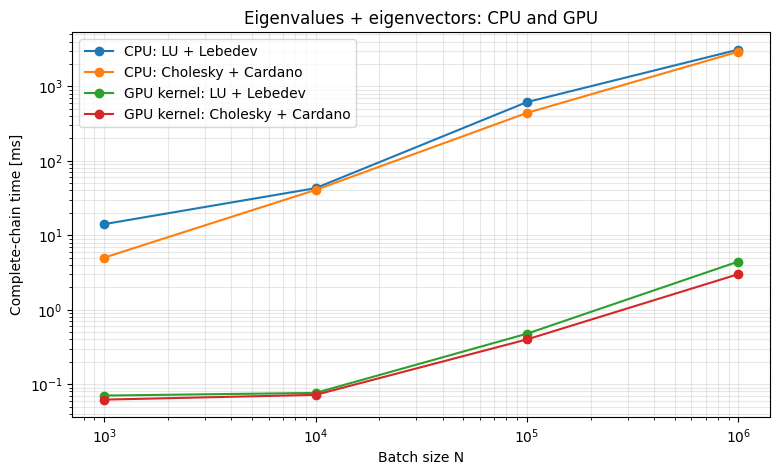

In [14]:

plt.figure(figsize=(9,5))
plt.loglog(
    results["N"],results["CPU LU+Lebedev [ms]"],
    "o-",label="CPU: LU + Lebedev"
)
plt.loglog(
    results["N"],results["CPU Cholesky+Cardano [ms]"],
    "o-",label="CPU: Cholesky + Cardano"
)
plt.loglog(
    results["N"],results["GPU LU+Lebedev kernel [ms]"],
    "o-",label="GPU kernel: LU + Lebedev"
)
plt.loglog(
    results["N"],results["GPU Cholesky+Cardano kernel [ms]"],
    "o-",label="GPU kernel: Cholesky + Cardano"
)
plt.xlabel("Batch size N")
plt.ylabel("Complete-chain time [ms]")
plt.title("Eigenvalues + eigenvectors: CPU and GPU")
plt.grid(True,which="both",alpha=0.3)
plt.legend()
plt.show()


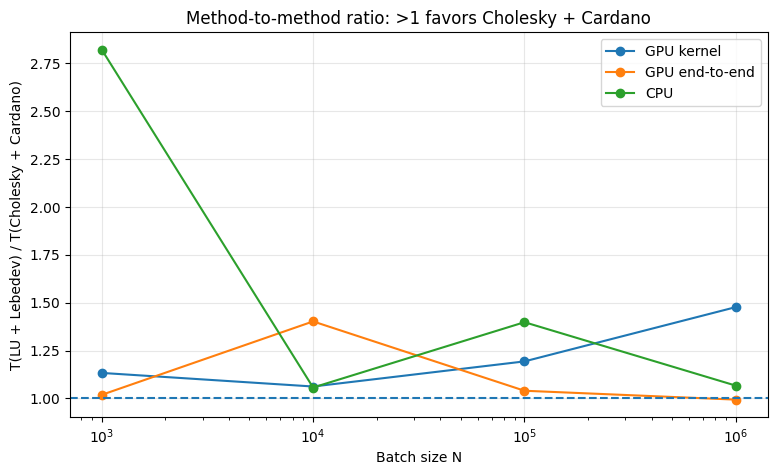

In [15]:

plt.figure(figsize=(9,5))
plt.semilogx(
    results["N"],results["GPU kernel ratio LU/Cholesky"],
    "o-",label="GPU kernel"
)
plt.semilogx(
    results["N"],results["GPU e2e ratio LU/Cholesky"],
    "o-",label="GPU end-to-end"
)
plt.semilogx(
    results["N"],results["CPU ratio LU/Cholesky"],
    "o-",label="CPU"
)
plt.axhline(1.0,linestyle="--")
plt.xlabel("Batch size N")
plt.ylabel("T(LU + Lebedev) / T(Cholesky + Cardano)")
plt.title("Method-to-method ratio: >1 favors Cholesky + Cardano")
plt.grid(True,alpha=0.3)
plt.legend()
plt.show()


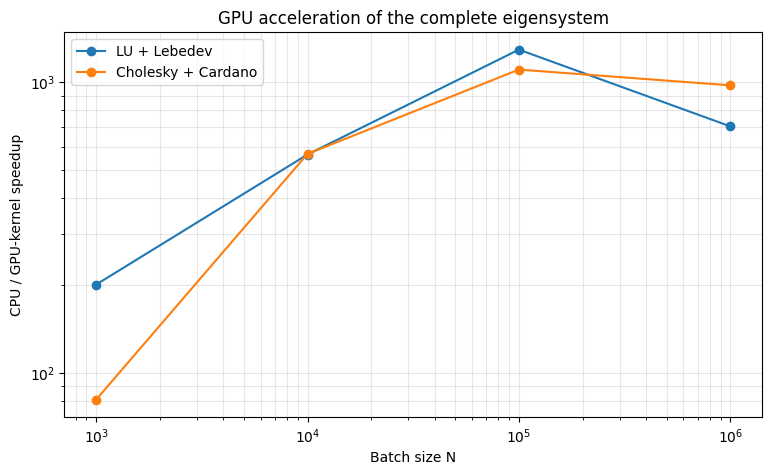

In [16]:

plt.figure(figsize=(9,5))
plt.loglog(
    results["N"],results["Lebedev CPU/GPU kernel speedup"],
    "o-",label="LU + Lebedev"
)
plt.loglog(
    results["N"],results["Cardano CPU/GPU kernel speedup"],
    "o-",label="Cholesky + Cardano"
)
plt.xlabel("Batch size N")
plt.ylabel("CPU / GPU-kernel speedup")
plt.title("GPU acceleration of the complete eigensystem")
plt.grid(True,which="both",alpha=0.3)
plt.legend()
plt.show()



## 13. Matched-filter interpretation

For

\[
\mathcal C(w)=\frac{w^H H w}{w^H G w},
\]

the maximum value is the largest generalized eigenvalue and the maximizing
polarimetric weight is the corresponding generalized eigenvector:

\[
\mathcal C_{\max}=\lambda_{\max},
\qquad
w_{\rm PMF}=w_{\max}.
\]

The present benchmark deliberately computes **all three eigenpairs**.  This gives a
complete numerical comparison and tests the full eigensystem.  A production PMF kernel
can be further optimized because only \((\lambda_{\max},w_{\max})\) is required.

The most application-relevant accuracy columns are therefore:

- `eig_rel_*`, especially the error on the largest eigenvalue;
- `dominant_vector_error_*`;
- `dominant_Rayleigh_rel_*`;
- generalized residuals.

For a repeated largest eigenvalue, a unique dominant vector does not exist; the
appropriate object is the dominant eigenspace.  The notebook excludes such
near-degenerate cases from the individual dominant-vector overlap statistic.
